In [ ]:
import kagglehub
import os
import glob
import shutil
import requests
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
import splitfolders
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt

In [1]:
# Download latest version
path = kagglehub.dataset_download("chuneeb/deepfake-detection-dataset-2026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deepfake-detection-dataset-2026' dataset.
Path to dataset files: /kaggle/input/deepfake-detection-dataset-2026


In [2]:
def download_dataset_images(kaggle_path, output_base="dataset", max_workers=8, clean=True):
  """
  Legge il CSV scaricato da Kaggle e scarica le immagini divise per label.
  Struttura output: output_base/data/<category>/<image_id>.<ext>

  FIX: il nome file usa 'image_id' (univoco) invece del basename dell'URL.
  Prima, url.split('/')[-1].split('?')[0] generava nomi duplicati -> dest.exists()
  scartava come "skip" migliaia di immagini DISTINTE (collisioni), riducendo
  il dataset da ~5500 a ~2450. Con image_id ogni immagine ha un nome unico.
  """
  if clean:
      shutil.rmtree(output_base, ignore_errors=True)
  csv_files = glob.glob(os.path.join(kaggle_path, "*.csv"))
  if not csv_files:
      raise FileNotFoundError(f"Nessun CSV trovato in {kaggle_path}")
  csv_path = csv_files[0]
  print(f"CSV trovato: {csv_path}")

  df = pd.read_csv(csv_path)
  print(f"Righe totali: {len(df)} | image_id unici: {df['image_id'].nunique()}")
  print(df['category'].value_counts().to_string())
  for label in df['category'].unique():
      Path(output_base, "data", label).mkdir(parents=True, exist_ok=True)
  print(f"\nCartelle create in '{output_base}/data/'")

  def download_one(row):
      url   = row['image_url']
      label = row['category']

      ext = os.path.splitext(url.split("?")[0])[1].lower()
      if ext not in (".jpg", ".jpeg", ".png", ".webp"):
          ext = ".jpg"

      filename = f"{row['image_id']}{ext}"
      dest = Path(output_base, "data", label, filename)
      if dest.exists():
          return "skip"
      try:
          r = requests.get(url, timeout=15, headers={"User-Agent": "Mozilla/5.0"})
          r.raise_for_status()
          if "image" not in r.headers.get("Content-Type", "").lower():
              return "err:not-image"
          dest.write_bytes(r.content)
          return "ok"
      except Exception as e:
          return f"err:{e}"

  rows = df.to_dict("records")
  ok, skip, errors = 0, 0, 0
  with ThreadPoolExecutor(max_workers=max_workers) as pool:
      futures = {pool.submit(download_one, row): row for row in rows}
      for fut in tqdm(as_completed(futures), total=len(futures), desc="Download"):
          result = fut.result()
          if result == "ok":     ok += 1
          elif result == "skip": skip += 1
          else:                  errors += 1

  print(f"\nCompletato — scaricate: {ok} | già presenti: {skip} | errori: {errors}")
download_dataset_images(path)

CSV trovato: /kaggle/input/deepfake-detection-dataset-2026/FINAL_DATASET.csv
Righe totali: 6557 | image_id unici: 6557
category
AI Generated    3767
Authentic       2790

Cartelle create in 'dataset/data/'


Download:   0%|          | 0/6557 [00:00<?, ?it/s]


Completato — scaricate: 5557 | già presenti: 0 | errori: 1000


In [3]:
!pip install split-folders

In [5]:
DATA_FILES = pathlib.Path("./dataset/data")

splitfolders.ratio(DATA_FILES, output="diviso", seed=42, ratio=(.8, .1, .1))

Copying files: 5557 files [00:04, 1302.06 files/s]


In [7]:
diviso = pathlib.Path("./diviso")

train_dir = diviso / "train"
val_dir = diviso / "val"
test_dir = diviso / "test"

SEED = 42
BATCH_SIZE = 16
IMG_SIZE = (300,300)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED
)


test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 4445 files belonging to 2 classes.
Found 555 files belonging to 2 classes.
Found 557 files belonging to 2 classes.


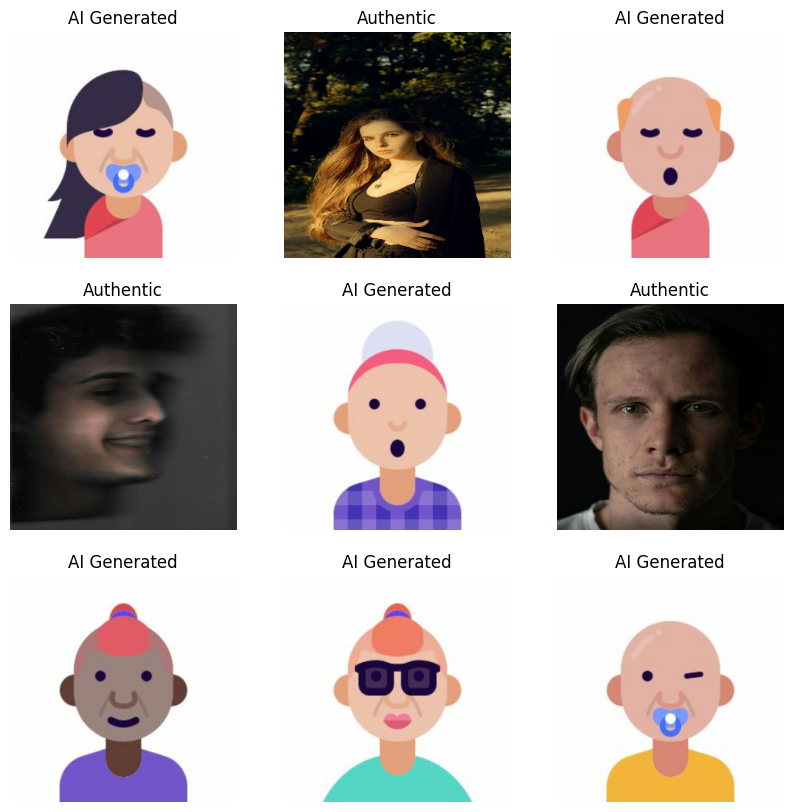

In [9]:
class_names = train_dataset.class_names

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [10]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

train_dataset  = train_dataset.cache().prefetch(2)
validation_dataset = validation_dataset.cache().prefetch(2)
test_dataset = test_dataset.cache().prefetch(2)

In [11]:
backbone = tf.keras.applications.EfficientNetB4(
    include_top = False,
    weights = "imagenet",
    input_shape = IMG_SIZE + (3,)
)

backbone.trainable = False

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [13]:
classification_heads = tf.keras.models.Sequential(
    [
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation = "relu"),
        tf.keras.layers.Dense(1, activation = "sigmoid")
    ]
)

In [14]:
inputs = tf.keras.layers.Input(shape = IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = data_augmentation(x)
x = backbone(x)
outputs = classification_heads(x)
model = tf.keras.Model(inputs, outputs)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

learning_rate_adapter = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3
)

checkpoint_model = tf.keras.callbacks.ModelCheckpoint(
    filepath="./best.keras",
    monitor="val_loss",
    save_best_only=True
)

checkpoint_weights = tf.keras.callbacks.ModelCheckpoint(
    filepath="./best.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True
)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate = 0.0001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=100,
    callbacks=[
        early_stopping,
        learning_rate_adapter,
        checkpoint_model,
        checkpoint_weights
    ]
)

Epoch 1/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 97s 262ms/step - accuracy: 0.9521 - loss: 0.1525 - val_accuracy: 0.9874 - val_loss: 0.0700 - learning_rate: 1.0000e-04
Epoch 2/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 58s 208ms/step - accuracy: 0.9843 - loss: 0.0636 - val_accuracy: 0.9892 - val_loss: 0.0545 - learning_rate: 1.0000e-04
Epoch 3/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 58s 210ms/step - accuracy: 0.9861 - loss: 0.0504 - val_accuracy: 0.9892 - val_loss: 0.0480 - learning_rate: 1.0000e-04
Epoch 4/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 58s 209ms/step - accuracy: 0.9876 - loss: 0.0427 - val_accuracy: 0.9892 - val_loss: 0.0471 - learning_rate: 1.0000e-04
Epoch 5/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 58s 209ms/step - accuracy: 0.9899 - loss: 0.0392 - val_accuracy: 0.9892 - val_loss: 0.0448 - learning_rate: 1.0000e-04
Epoch 6/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 58s 209ms/step - accuracy: 0.9906 - loss: 0.0337 - val_accuracy: 0.9910 - val_loss: 0.0423 - learning_rate: 1.0000e-04
Epoch 7/100
278/278 ━━━━━━━━━━━━━━━━━━━━

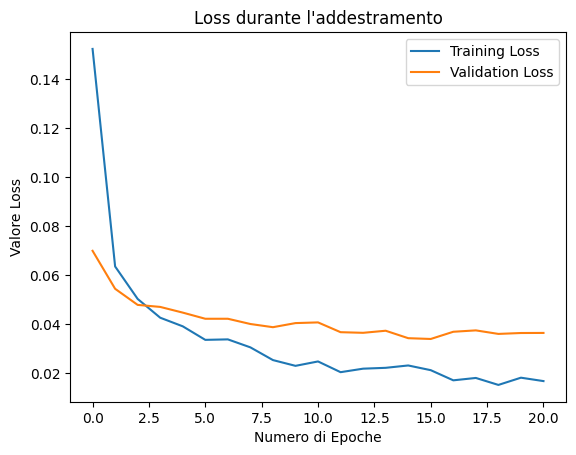

In [18]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel("Numero di Epoche")
plt.ylabel("Valore Loss")
plt.title("Loss durante l'addestramento")
plt.show()

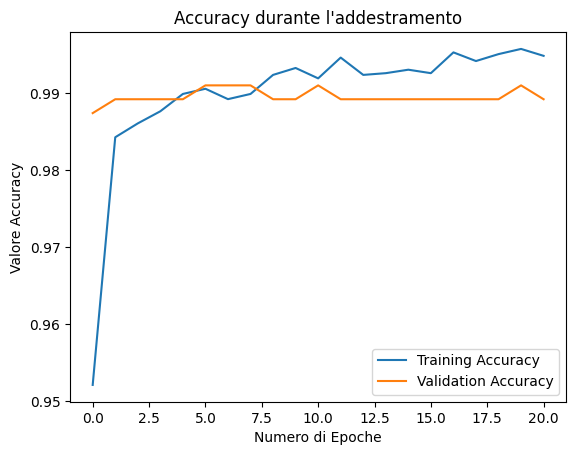

In [19]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Numero di Epoche")
plt.ylabel("Valore Accuracy")
plt.title("Accuracy durante l'addestramento")
plt.show()

In [20]:
best_model = tf.keras.models.load_model("./best.keras")

model.load_weights("./best.weights.h5")

results = model.evaluate(test_dataset)
print(f'Accuracy : {results[1]}')

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.9838 - loss: 0.0539
Accuracy : 0.9838420152664185
